In [1]:
import cv2
import numpy as np
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt

In [ ]:
img_rgb = cv2.imread('img1.jpg' , cv2.IMREAD_COLOR_RGB)
plt.imshow(img_rgb)
plt.show()

In [4]:
Q_LUMINANCE = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
])

Q_CHROMINANCE = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
])


In [6]:
def rgb_to_ycbcr(img_rgb):
    img_float = img_rgb.astype(np.float32)/255.0
    img_ycbcr = cv2.cvtColor(img_float, cv2.COLOR_RGB2YCrCb)
    Y, Cr, Cb = cv2.split(img_ycbcr)       
    return Y, Cb, Cr                    

In [7]:
def chroma_subsampling(Cb, Cr, ratio=(2, 2)):
    Cb_sub = cv2.resize(Cb, (0, 0), fx=1/ratio[0], fy=1/ratio[1], interpolation=cv2.INTER_AREA)
    Cr_sub = cv2.resize(Cr, (0, 0), fx=1/ratio[0], fy=1/ratio[1], interpolation=cv2.INTER_AREA)
    return Cb_sub, Cr_sub

In [8]:

def forward_dct_and_quantize(channel, Q_table):
    h, w = channel.shape
    pad_h = (8 - (h % 8)) % 8
    pad_w = (8 - (w % 8)) % 8
    padded_channel = np.pad(channel, ((0, pad_h), (0, pad_w)), 'edge')
    h_padded, w_padded = padded_channel.shape
    quantized_blocks = np.zeros_like(padded_channel, dtype=np.int32)
    shifted_channel = padded_channel - 128
    
    for i in range(0, h_padded, 8):
        for j in range(0, w_padded, 8):
            block = shifted_channel[i:i+8, j:j+8]
            def dct2(a):
                return dct(dct(a.T, norm='ortho').T, norm='ortho')
            
            dct_block = dct2(block)
            quantized_block = np.round(dct_block / Q_table).astype(np.int32)
            quantized_blocks[i:i+8, j:j+8] = quantized_block
            
    return quantized_blocks, (h, w)

In [ ]:
def entropy_encoder_decoder_simulation(quantized_data):
    compressed_data = quantized_data
    decompressed_data = compressed_data
    return decompressed_data

In [9]:
def inverse_dequantize_and_idct(quantized_blocks, Q_table, original_shape):

    h_orig, w_orig = original_shape
    h_padded, w_padded = quantized_blocks.shape
    reconstructed_channel = np.zeros_like(quantized_blocks, dtype=np.float32)
    
    for i in range(0, h_padded, 8):
        for j in range(0, w_padded, 8):
            quantized_block = quantized_blocks[i:i+8, j:j+8]
            dequantized_block = quantized_block * Q_table
            def idct2(a):
                return idct(idct(a.T, norm='ortho').T, norm='ortho')
            reconstructed_block = idct2(dequantized_block)
            reconstructed_channel[i:i+8, j:j+8] = reconstructed_block
            
    reconstructed_channel += 128
    final_channel = reconstructed_channel[:h_orig, :w_orig]
    final_channel = np.clip(final_channel, 0, 255)
    
    return final_channel

In [10]:
def chroma_upsampling(Cb_sub, Cr_sub, Y_shape, ratio=(2, 2)):
    h_Y, w_Y = Y_shape
    Cb_up = cv2.resize(Cb_sub, (w_Y, h_Y), interpolation=cv2.INTER_LINEAR)
    Cr_up = cv2.resize(Cr_sub, (w_Y, h_Y), interpolation=cv2.INTER_LINEAR)
    
    return Cb_up, Cr_up

In [ ]:
def ycbcr_to_rgb(Y, Cb, Cr):
    img_ycbcr = cv2.merge([Y, Cr, Cb])
    img_rgb = cv2.cvtColor(img_ycbcr, cv2.COLOR_YCrCb2RGB)
    return img_rgb  

In [ ]:
def jpeg_compression_decompression(img_rgb, output_path="reconstructed_image.png"):
    Y, Cb, Cr = rgb_to_ycbcr(img_rgb)
    Cb_sub, Cr_sub = chroma_subsampling(Cb, Cr)
    Y_quantized, Y_shape = forward_dct_and_quantize(Y, Q_LUMINANCE)
    Cb_quantized, Cb_shape = forward_dct_and_quantize(Cb_sub, Q_CHROMINANCE)
    Cr_quantized, Cr_shape = forward_dct_and_quantize(Cr_sub, Q_CHROMINANCE)
    compressed_Y = entropy_encoder_decoder_simulation(Y_quantized)
    compressed_Cb = entropy_encoder_decoder_simulation(Cb_quantized)
    compressed_Cr = entropy_encoder_decoder_simulation(Cr_quantized)
    decompressed_Y = entropy_encoder_decoder_simulation(compressed_Y)
    decompressed_Cb = entropy_encoder_decoder_simulation(compressed_Cb)
    decompressed_Cr = entropy_encoder_decoder_simulation(compressed_Cr)
    Y_reconstructed = inverse_dequantize_and_idct(decompressed_Y, Q_LUMINANCE, Y_shape)
    Cb_reconstructed = inverse_dequantize_and_idct(decompressed_Cb, Q_CHROMINANCE, Cb_shape)
    Cr_reconstructed = inverse_dequantize_and_idct(decompressed_Cr, Q_CHROMINANCE, Cr_shape)
    Cb_up, Cr_up = chroma_upsampling(Cb_reconstructed, Cr_reconstructed, Y_reconstructed.shape)
    img_reconstructed_rgb = ycbcr_to_rgb(Y_reconstructed, Cb_up, Cr_up)
    cv2.imwrite(output_path, cv2.cvtColor(img_reconstructed_rgb, cv2.COLOR_RGB2BGR))

jpeg_compression_decompression(img_rgb , "reconstructed.jpg")

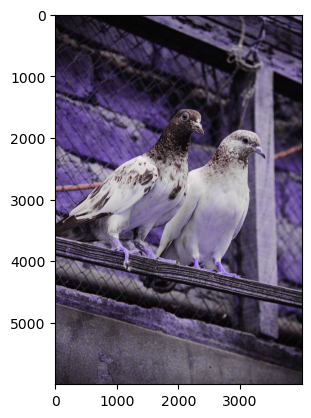

In [15]:
img = cv2.imread('reconstructed.jpg' )
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()